<a href="https://colab.research.google.com/github/TottiPuc/Machine_learning/blob/master/Annova_Insurance_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anova Insurance — Health Risk Classification with Logistic Regression

## Project objective

Anova Insurance wants to use applicant health information to support two business decisions:

1. Determine eligibility for health insurance coverage.
2. Support premium pricing decisions when the applicant's health profile indicates higher risk.

The machine learning task is a **binary classification problem**:

- `0` = **Healthy**
- `1` = **Unhealthy**


## 1. Import libraries

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TARGET = "Target"

## 2. Load the dataset



In [ ]:
from google.colab import files

uploaded = files.upload()

csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]

data_path = csv_files[0]


df_raw = pd.read_csv(data_path)

print(f"Loaded file: {data_path}")
print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())

Saving Healthcare_Dataset_Preprocessed.csv to Healthcare_Dataset_Preprocessed.csv
Loaded file: Healthcare_Dataset_Preprocessed.csv
Dataset shape: (9549, 23)


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,1,2,2,1,2,1,0,1,0,1,1,0,0
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,1,0,1,1,2,1,2,2,0,0,1,0,0
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,0,2,1,2,0,0,1,0,1,0,0,0,0
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,0,2,0,1,2,1,2,0,1,0,0,1,0
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,0,0,1,2,0,2,0,2,0,1,0,1,0


## 3. Inspect structure, data types, and cardinality

In [ ]:
print("Dataset shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nUnique values per column:")
display(
    df_raw.nunique()
          .sort_values()
          .to_frame("unique_values")
)

print("\nDescriptive statistics:")
display(df_raw.describe().T)

Dataset shape: (9549, 23)

Column names:
['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level', 'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake', 'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth', 'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type_Vegan', 'Diet_Type_Vegetarian', 'Blood_Group_AB', 'Blood_Group_B', 'Blood_Group_O']

Data types:


,dtype
Age,float64
BMI,float64
Blood_Pressure,float64
Cholesterol,float64
Glucose_Level,float64
Heart_Rate,float64
Sleep_Hours,float64
Exercise_Hours,float64
Water_Intake,float64
Stress_Level,float64



Unique values per column:


,unique_values
Target,2
Blood_Group_B,2
Diet_Type_Vegan,2
Blood_Group_O,2
Blood_Group_AB,2
Diet_Type_Vegetarian,2
PhysicalActivity,3
Alcohol,3
Smoking,3
MedicalHistory,3



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Age,9549.0,33.806786,24.566473,0.0,14.0,29.0,50.0,100.0
BMI,9549.0,25.660697,1.942369,19.0,24.0,26.0,27.0,32.0
Blood_Pressure,9549.0,130.382658,27.878476,22.0,113.0,134.0,150.0,225.0
Cholesterol,9549.0,199.091528,1.969234,192.0,198.0,199.0,200.0,207.0
Glucose_Level,9549.0,100.225678,2.157999,93.0,99.0,100.0,102.0,107.0
Heart_Rate,9549.0,73.613782,1.681538,67.0,73.0,74.0,75.0,80.0
Sleep_Hours,9549.0,6.951409,2.352152,0.0,5.0,7.0,9.0,14.0
Exercise_Hours,9549.0,1.892345,1.378714,-0.0,1.0,2.0,3.0,8.0
Water_Intake,9549.0,3.580899,1.622874,-0.0,2.0,4.0,5.0,10.0
Stress_Level,9549.0,4.382134,2.078593,0.0,3.0,4.0,6.0,12.0


## 4. Audit missing values, infinite values, and duplicates



In [ ]:
quality_report = pd.DataFrame({
    "missing_values": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(3),
    "infinite_values": [
        np.isinf(pd.to_numeric(df_raw[c], errors="coerce")).sum()
        if pd.api.types.is_numeric_dtype(df_raw[c]) else 0
        for c in df_raw.columns
    ],
    "unique_values": df_raw.nunique()
})

print(f"Exact duplicate rows: {df_raw.duplicated().sum()}")
display(quality_report.sort_values(["missing_values", "infinite_values"], ascending=False))

Exact duplicate rows: 0


,missing_values,missing_percent,infinite_values,unique_values
Age,0,0.0,0,101
BMI,0,0.0,0,14
Blood_Pressure,0,0.0,0,175
Cholesterol,0,0.0,0,16
Glucose_Level,0,0.0,0,15
Heart_Rate,0,0.0,0,14
Sleep_Hours,0,0.0,0,15
Exercise_Hours,0,0.0,0,9
Water_Intake,0,0.0,0,11
Stress_Level,0,0.0,0,13


## 5. Safe cleaning



In [ ]:
df = df_raw.copy()

df.columns = [c.strip() for c in df.columns]

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="raise")

df = df.replace([np.inf, -np.inf], np.nan)

rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' was not found.")

target_values = set(df[TARGET].dropna().unique())
if not target_values.issubset({0, 1}):
    raise ValueError(f"Unexpected target values found: {sorted(target_values)}")

print(f"Rows before duplicate removal: {rows_before}")
print(f"Rows after duplicate removal:  {rows_after}")
print(f"Rows removed:                 {rows_before - rows_after}")
print(f"Remaining missing values:     {int(df.isna().sum().sum())}")
print(f"Target values:                {sorted(target_values)}")

Rows before duplicate removal: 9549
Rows after duplicate removal:  9549
Rows removed:                 0
Remaining missing values:     0
Target values:                [np.int64(0), np.int64(1)]


## 6. Range and outlier audit



In [ ]:
continuous_columns = [
    "Age",
    "BMI",
    "Blood_Pressure",
    "Cholesterol",
    "Glucose_Level",
    "Heart_Rate",
    "Sleep_Hours",
    "Exercise_Hours",
    "Water_Intake",
    "Stress_Level"
]

continuous_columns = [c for c in continuous_columns if c in df.columns]

range_report = pd.DataFrame({
    "min": df[continuous_columns].min(),
    "q1": df[continuous_columns].quantile(0.25),
    "median": df[continuous_columns].median(),
    "q3": df[continuous_columns].quantile(0.75),
    "max": df[continuous_columns].max(),
})

iqr_outliers = []
for col in continuous_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    iqr_outliers.append({
        "feature": col,
        "lower_iqr_bound": lower,
        "upper_iqr_bound": upper,
        "iqr_outlier_count": int(count),
        "iqr_outlier_percent": round(100 * count / len(df), 3)
    })

display(range_report)
display(pd.DataFrame(iqr_outliers).set_index("feature"))

if "Blood_Pressure" in df.columns:
    print(
        "Blood_Pressure values below 50:",
        int((df["Blood_Pressure"] < 50).sum())
    )

,min,q1,median,q3,max
Age,0.0,14.0,29.0,50.0,100.0
BMI,19.0,24.0,26.0,27.0,32.0
Blood_Pressure,22.0,113.0,134.0,150.0,225.0
Cholesterol,192.0,198.0,199.0,200.0,207.0
Glucose_Level,93.0,99.0,100.0,102.0,107.0
Heart_Rate,67.0,73.0,74.0,75.0,80.0
Sleep_Hours,0.0,5.0,7.0,9.0,14.0
Exercise_Hours,-0.0,1.0,2.0,3.0,8.0
Water_Intake,-0.0,2.0,4.0,5.0,10.0
Stress_Level,0.0,3.0,4.0,6.0,12.0


,lower_iqr_bound,upper_iqr_bound,iqr_outlier_count,iqr_outlier_percent
feature,,,,
Age,-40.0,104.0,0,0.000
BMI,19.5,31.5,16,0.168
Blood_Pressure,57.5,205.5,75,0.785
Cholesterol,195.0,203.0,218,2.283
Glucose_Level,94.5,106.5,43,0.450
Heart_Rate,70.0,78.0,83,0.869
Sleep_Hours,-1.0,15.0,0,0.000
Exercise_Hours,-2.0,6.0,29,0.304
Water_Intake,-2.5,9.5,2,0.021


Blood_Pressure values below 50: 25


### Cleaning conclusion for the dataset

This CSV shows that the dataset has already been strongly preprocessed:

- No missing values.
- No duplicate rows.
- No negative ages.
- All variables are numeric.
- Target is binary.
- Diet and blood-group dummy variables are internally consistent.



## 7. Target distribution and class balance



,count,percent
Healthy (0),4570,47.86
Unhealthy (1),4979,52.14


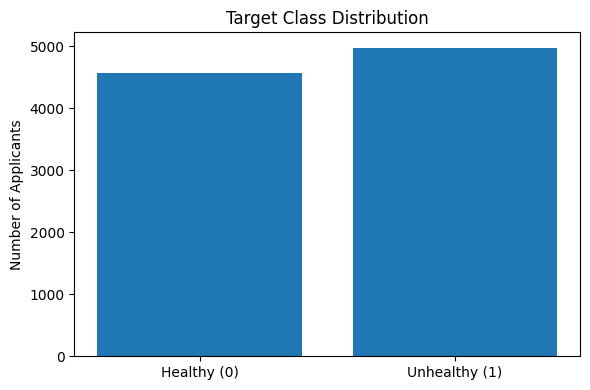

In [ ]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct = (df[TARGET].value_counts(normalize=True).sort_index() * 100)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_pct.round(2)
})
target_summary.index = ["Healthy (0)", "Unhealthy (1)"]

display(target_summary)

plt.figure(figsize=(6, 4))
plt.bar(["Healthy (0)", "Unhealthy (1)"], target_counts.values)
plt.title("Target Class Distribution")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

## 8. Numerical feature distributions



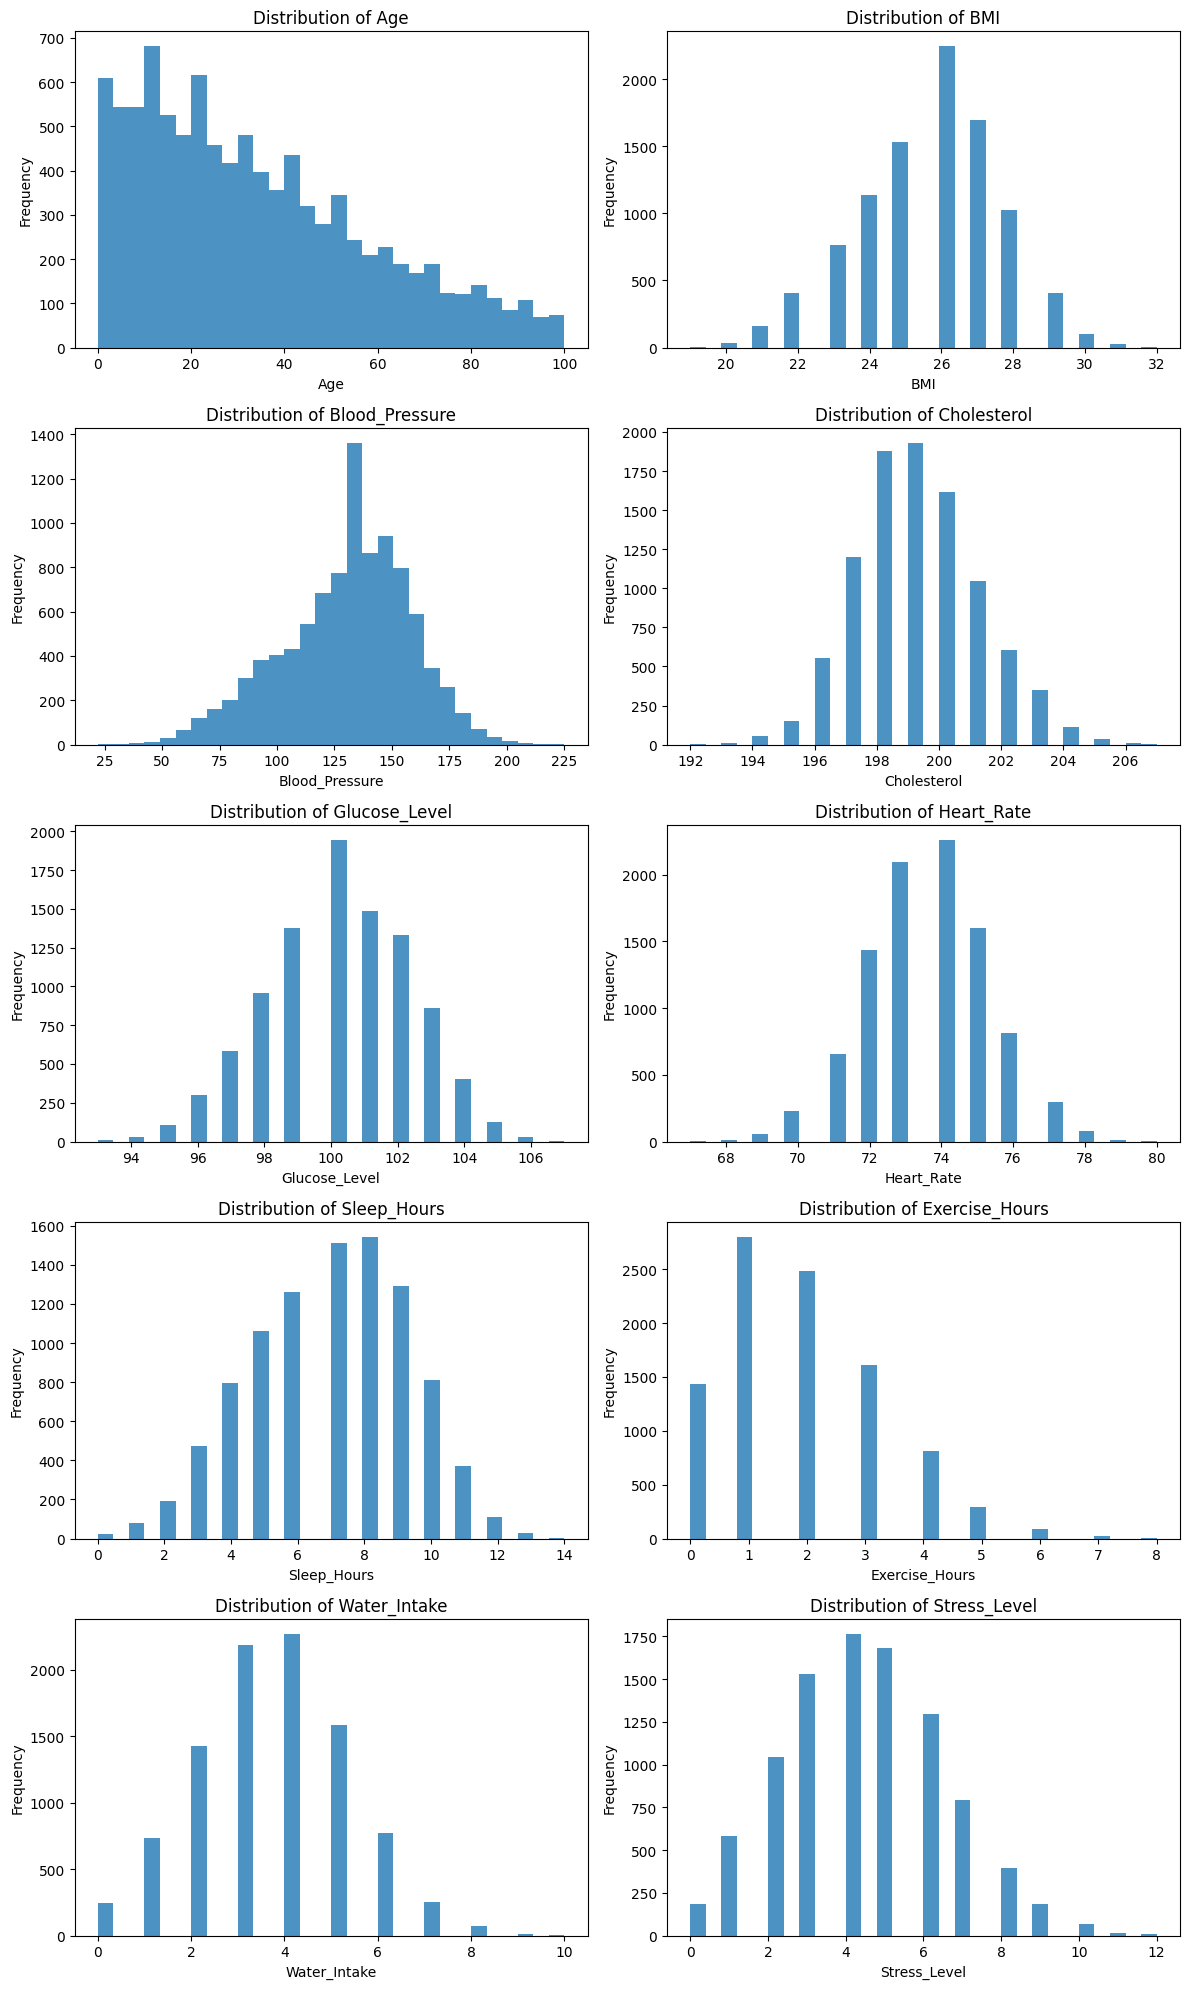

In [ ]:
n_cols = 2
n_rows = int(np.ceil(len(continuous_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, continuous_columns):
    ax.hist(df[col], bins=30, alpha=0.8)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(continuous_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Numerical features by target class



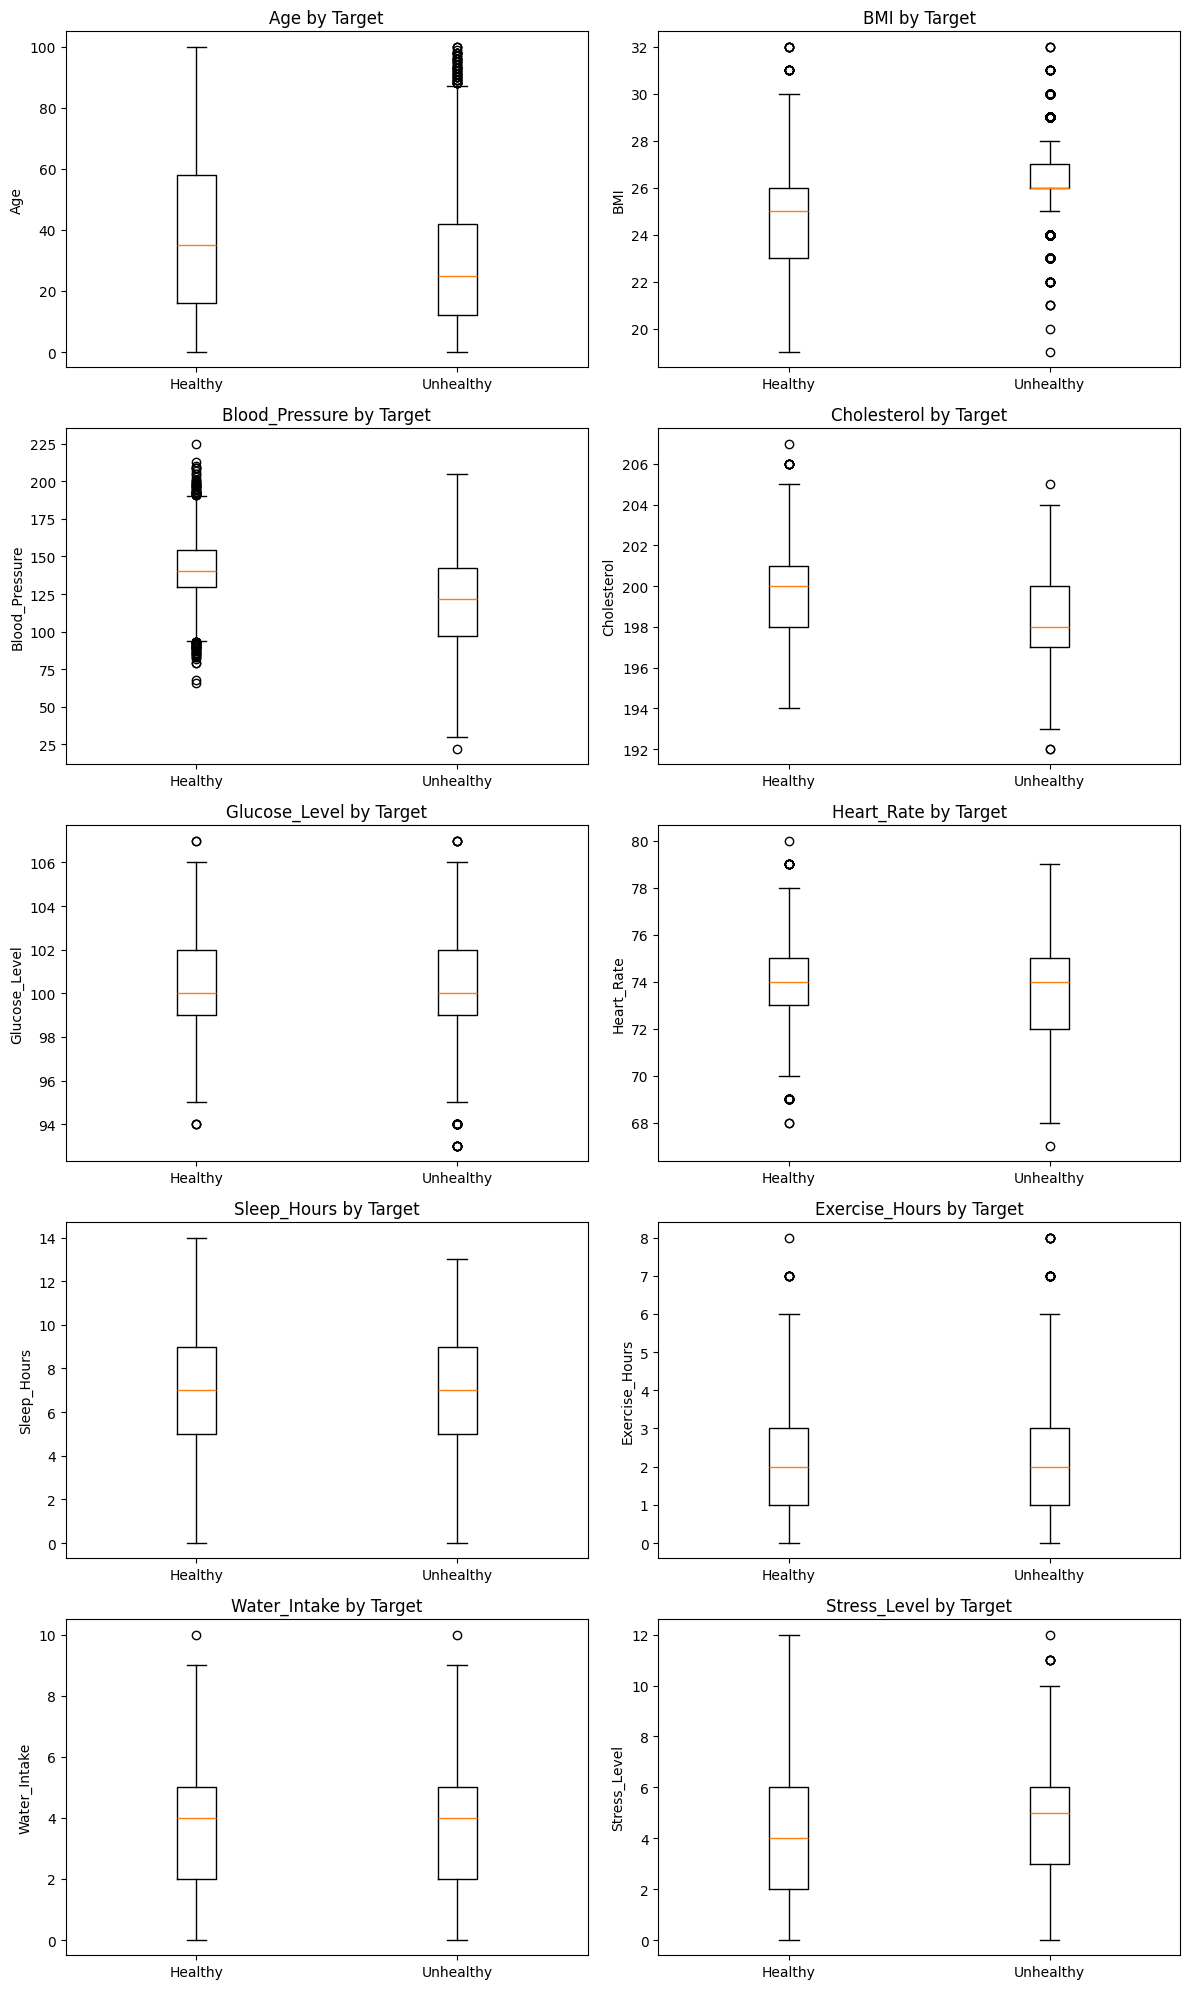

In [ ]:
n_cols = 2
n_rows = int(np.ceil(len(continuous_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, continuous_columns):
    healthy = df.loc[df[TARGET] == 0, col].dropna()
    unhealthy = df.loc[df[TARGET] == 1, col].dropna()

    ax.boxplot(
        [healthy, unhealthy],
        tick_labels=["Healthy", "Unhealthy"],
        showfliers=True
    )
    ax.set_title(f"{col} by Target")
    ax.set_ylabel(col)

for ax in axes[len(continuous_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 10. Mean profile by class

In [ ]:
profile_columns = [
    c for c in continuous_columns + ordinal_columns
    if c in df.columns
]

class_profile = df.groupby(TARGET)[profile_columns].mean().T
class_profile.columns = ["Healthy_mean", "Unhealthy_mean"]
class_profile["difference_Unhealthy_minus_Healthy"] = (
    class_profile["Unhealthy_mean"] - class_profile["Healthy_mean"]
)

display(
    class_profile.sort_values(
        "difference_Unhealthy_minus_Healthy",
        key=np.abs,
        ascending=False
    )
)

,Healthy_mean,Unhealthy_mean,difference_Unhealthy_minus_Healthy
Blood_Pressure,141.447921,120.226351,-21.221571
Age,38.697593,29.317734,-9.379859
BMI,24.821444,26.431010,1.609566
Cholesterol,199.758206,198.479614,-1.278591
Stress_Level,4.122976,4.620004,0.497028
Glucose_Level,100.388184,100.076521,-0.311662
Heart_Rate,73.729540,73.507532,-0.222009
Water_Intake,3.645952,3.521189,-0.124763
Sleep_Hours,6.887746,7.009841,0.122095
MentalHealth,1.012473,0.985539,-0.026933


## 11. Correlation analysis



Features ranked by absolute correlation with Target:


,correlation_with_target
BMI,0.413972
Blood_Pressure,-0.380279
Cholesterol,-0.324361
Age,-0.190743
Stress_Level,0.119455
Glucose_Level,-0.072148
Heart_Rate,-0.065957
Water_Intake,-0.038406
Sleep_Hours,0.025931
Diet_Type_Vegan,0.023707


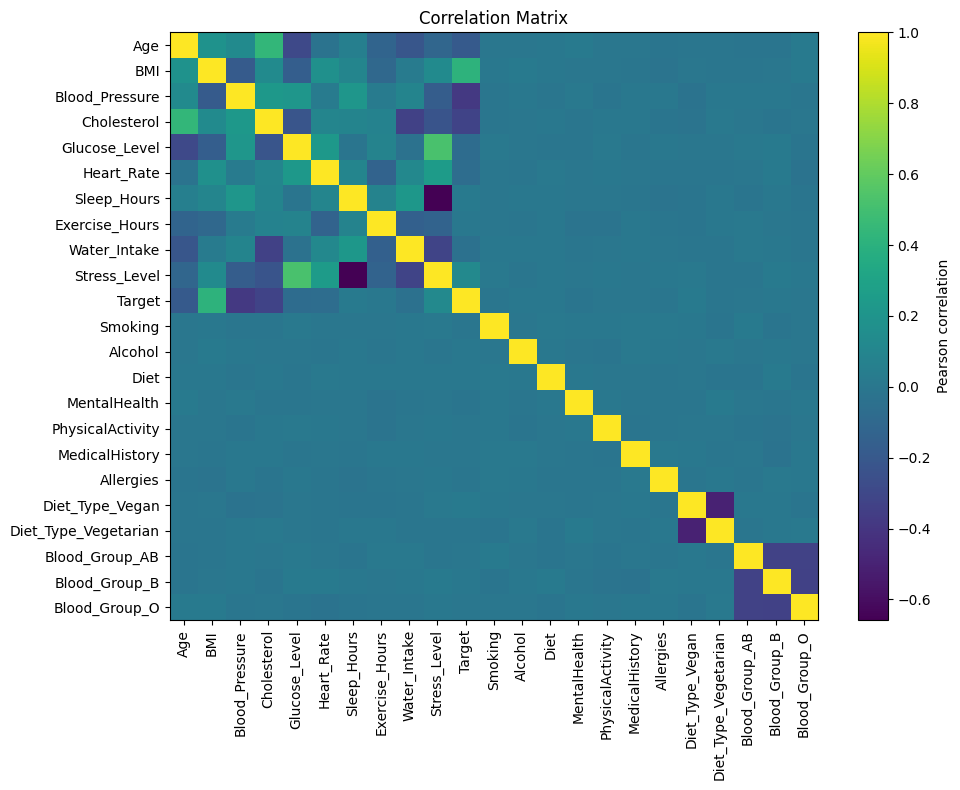

In [ ]:
corr_matrix = df.corr(numeric_only=True)

target_corr = (
    corr_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

print("Features ranked by absolute correlation with Target:")
display(target_corr.to_frame("correlation_with_target"))

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto", interpolation="nearest")
plt.colorbar(label="Pearson correlation")
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 12. Train/test split

A stratified split preserves the target-class proportion.

In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

print("\nTraining target distribution:")
display((y_train.value_counts(normalize=True).sort_index() * 100).round(2).to_frame("%"))

print("Test target distribution:")
display((y_test.value_counts(normalize=True).sort_index() * 100).round(2).to_frame("%"))

Training set: (7639, 22)
Test set:     (1910, 22)

Training target distribution:


,%
Target,
0,47.86
1,52.14


Test target distribution:


,%
Target,
0,47.85
1,52.15


## 13. Baseline pipeline

Standardization is important because Logistic Regression regularization depends on feature scale.

In [ ]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

In [ ]:
def classification_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

baseline_metrics = classification_metrics(
    y_test,
    baseline_pred,
    baseline_prob
)

display(
    pd.DataFrame(
        baseline_metrics.items(),
        columns=["Metric", "Baseline Logistic Regression"]
    ).style.format({"Baseline Logistic Regression": "{:.4f}"})
)

print(classification_report(
    y_test,
    baseline_pred,
    target_names=["Healthy", "Unhealthy"],
    zero_division=0
))

,Metric,Baseline Logistic Regression
0,Accuracy,0.8136
1,Precision,0.8175
2,Recall,0.8273
3,F1-score,0.8224
4,ROC-AUC,0.8879


              precision    recall  f1-score   support

     Healthy       0.81      0.80      0.80       914
   Unhealthy       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



## 14. Cross-validation baseline

Five-fold stratified cross-validation provides a more stable estimate using the training data only.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

baseline_cv = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_cv_summary = pd.DataFrame({
    metric: [
        baseline_cv[f"test_{metric}"].mean(),
        baseline_cv[f"test_{metric}"].std()
    ]
    for metric in scoring
}, index=["mean", "std"]).T

display(baseline_cv_summary.style.format("{:.4f}"))

,mean,std
accuracy,0.8176,0.0104
precision,0.8152,0.0150
recall,0.8413,0.0122
f1,0.8279,0.0091
roc_auc,0.8893,0.0105


# Improve Logistic Regression

## 15. Cross-validated hyperparameter search

The search is performed on the training set only.



In [ ]:
improved_pipeline = Pipeline([
    ("polynomial_features", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "polynomial_features__degree": [1, 2],
    "logistic_regression__C": [0.01, 0.03, 0.1, 0.3, 1.0],
    "logistic_regression__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=improved_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters:")
print(grid_search.best_params_)
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Best hyperparameters:
{'logistic_regression__C': 1.0, 'logistic_regression__class_weight': 'balanced', 'polynomial_features__degree': 2}
Best cross-validated ROC-AUC: 0.9493


## 16. Inspect the hyperparameter search results

In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)

result_columns = [
    "param_polynomial_features__degree",
    "param_logistic_regression__C",
    "param_logistic_regression__class_weight",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]

display(
    cv_results[result_columns]
    .sort_values("mean_test_score", ascending=False)
    .head(12)
    .rename(columns={
        "mean_test_score": "mean_cv_ROC_AUC",
        "std_test_score": "std_cv_ROC_AUC",
        "mean_train_score": "mean_train_ROC_AUC"
    })
)

,param_polynomial_features__degree,param_logistic_regression__C,param_logistic_regression__class_weight,mean_cv_ROC_AUC,std_cv_ROC_AUC,mean_train_ROC_AUC
19,2,1.00,balanced,0.949301,0.004654,0.959920
17,2,1.00,None,0.949188,0.004644,0.959761
15,2,0.30,balanced,0.937720,0.005691,0.948725
13,2,0.30,None,0.937610,0.005700,0.948562
11,2,0.10,balanced,0.926714,0.007000,0.937742
9,2,0.10,None,0.926637,0.007091,0.937608
7,2,0.03,balanced,0.915944,0.008476,0.926224
5,2,0.03,None,0.915866,0.008547,0.926113
3,2,0.01,balanced,0.908193,0.009502,0.916776
1,2,0.01,None,0.908143,0.009533,0.916696


## 17. Evaluate the selected model on the untouched test set

In [ ]:
improved_pred_05 = best_model.predict(X_test)
improved_prob = best_model.predict_proba(X_test)[:, 1]

improved_metrics_05 = classification_metrics(
    y_test,
    improved_pred_05,
    improved_prob
)

model_comparison = pd.DataFrame({
    "Baseline Logistic Regression": baseline_metrics,
    "Improved Logistic Regression": improved_metrics_05
}).T

display(model_comparison.style.format("{:.4f}"))

print("\nImproved model classification report at threshold = 0.50:")
print(classification_report(
    y_test,
    improved_pred_05,
    target_names=["Healthy", "Unhealthy"],
    zero_division=0
))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Baseline Logistic Regression,0.8136,0.8175,0.8273,0.8224,0.8879
Improved Logistic Regression,0.8953,0.8956,0.9046,0.9001,0.9557



Improved model classification report at threshold = 0.50:
              precision    recall  f1-score   support

     Healthy       0.89      0.89      0.89       914
   Unhealthy       0.90      0.90      0.90       996

    accuracy                           0.90      1910
   macro avg       0.90      0.89      0.90      1910
weighted avg       0.90      0.90      0.90      1910



## 18. Check for overfitting

A large gap between training and test performance would indicate overfitting.



In [ ]:
train_prob = best_model.predict_proba(X_train)[:, 1]
train_pred = best_model.predict(X_train)

generalization_check = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, train_pred),
        f1_score(y_train, train_pred),
        roc_auc_score(y_train, train_prob)
    ],
    "Test": [
        accuracy_score(y_test, improved_pred_05),
        f1_score(y_test, improved_pred_05),
        roc_auc_score(y_test, improved_prob)
    ]
}, index=["Accuracy", "F1-score", "ROC-AUC"])

generalization_check["Absolute gap"] = (
    generalization_check["Train"] - generalization_check["Test"]
).abs()

display(generalization_check.style.format("{:.4f}"))

,Train,Test,Absolute gap
Accuracy,0.9012,0.8953,0.0059
F1-score,0.9056,0.9001,0.0055
ROC-AUC,0.9608,0.9557,0.0051
